# Modelado (XGBoost) — Predicción de éxito

Este notebook:
- Carga el dataset model-ready (`02_feature_engineering`).
- Preprocesa: One-Hot para categóricas.
- Entrena XGBoost con control de desbalanceo.
- Evalúa y guarda el modelo.


## 0) Setup


In [5]:
# !pip install -U pandas numpy scikit-learn xgboost joblib matplotlib

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix, precision_recall_curve
)

import matplotlib.pyplot as plt
from xgboost import XGBClassifier

RANDOM_STATE = 42


## 1) Cargar dataset


In [6]:
data_path = Path("C:/Users/crisr/dev/rawg-aws-ml-analytics/notas_cris/00_data/train_dataset.parquet")
if not data_path.exists():
    raise FileNotFoundError("No encuentro data/processed/train_dataset.parquet. Ejecuta primero feature_engineering.")

df = pd.read_parquet(data_path)
df.shape, df.head(3)


((137179, 25),
    game_id                game_name  game_rating  ratings_count  game_added  \
 0       10    G Prime Into The Rain          0.0              5          69   
 1       11  Replay: VHS is not dead          0.0              4           9   
 2       13   MagNets: Fully Charged          0.0              2           6   
 
    suggestions_count  playtime  playing  owned  toplay  ...  release_year  \
 0                266         1        0     63       1  ...          2016   
 1                395         0        0      6       0  ...          2016   
 2                156         0        0      4       0  ...          2016   
 
    has_multiplayer  has_singleplayer  is_indie rating_popularity_ratio  \
 0                0                 1         1                     0.0   
 1                0                 0         0                     0.0   
 2                1                 0         0                     0.0   
 
    engagement_score  years_since_release  qual

In [7]:
df.columns



Index(['game_id', 'game_name', 'game_rating', 'ratings_count', 'game_added',
       'suggestions_count', 'playtime', 'playing', 'owned', 'toplay',
       'num_platforms', 'num_stores', 'num_genres', 'num_tags', 'esrb_name',
       'release_year', 'has_multiplayer', 'has_singleplayer', 'is_indie',
       'rating_popularity_ratio', 'engagement_score', 'years_since_release',
       'quality_confidence', 'recency_score', 'is_success_v2'],
      dtype='object')

## 2) Definir X / y


In [8]:
"""
Para evitar proxy leakage se excluyen variables de popularidad directa:
- owned
- toplay
- suggestions_count
- game_added
- playing
- rating_popularity_ratio
- engagement_score
- quality_confidence

"""


'\nPara evitar proxy leakage se excluyen variables de popularidad directa:\n- owned\n- toplay\n- suggestions_count\n- game_added\n- playing\n- rating_popularity_ratio\n- engagement_score\n- quality_confidence\n\n'

In [9]:
 ALL_NUMERIC_FEATURES = [
     'game_rating', 'ratings_count',
    'game_added', 'suggestions_count',
    'playtime', 'playing', 'owned', 'toplay',
    'num_platforms', 'num_stores', 'num_genres', 'num_tags',
    'rating_popularity_ratio', 'engagement_score',
    'years_since_release', 'quality_confidence',
    'recency_score'
]

LEAKAGE_FEATURES = [
    'game_rating','ratings_count','game_added','playtime','playing',
    'rating_popularity_ratio','quality_confidence','engagement_score',
    'owned','toplay','suggestions_count'
]

NUMERIC_FEATURES = [
    f for f in ALL_NUMERIC_FEATURES
    if f not in LEAKAGE_FEATURES
]

CATEGORICAL_FEATURES = [
    'esrb_name', 'release_year',
    'has_multiplayer', 'has_singleplayer', 'is_indie'
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

TARGET = "is_success_v2"

X = df[FEATURES].copy()
y = df[TARGET].astype(int)

y.value_counts(normalize=True)

print("X columns:", X.columns.tolist())
print("suggestions_count en X?", "suggestions_count" in X.columns)


X columns: ['num_platforms', 'num_stores', 'num_genres', 'num_tags', 'years_since_release', 'recency_score', 'esrb_name', 'release_year', 'has_multiplayer', 'has_singleplayer', 'is_indie']
suggestions_count en X? False


## 3) Split train/test


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("suggestions_count en X_train?", "suggestions_count" in X_train.columns)
print(X_train.shape, X_test.shape)



suggestions_count en X_train? False
(109743, 11) (27436, 11)


## 4) Preprocesado


In [11]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", "passthrough", NUMERIC_FEATURES),
    ],
    remainder="drop",
)


## 5) Entrenamiento XGBoost


In [12]:
pos = int(y_train.sum())
neg = int((y_train == 0).sum())
scale_pos_weight = (neg / max(pos, 1))

scale_pos_weight


2.889526847421584

In [13]:
xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("xgb", xgb),
])

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

roc = roc_auc_score(y_test, y_proba)
pr = average_precision_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

roc, pr, f1


(np.float64(0.9058790122552082),
 np.float64(0.8182706347581359),
 0.7379963664676875)

## 6) Reporte + matriz de confusión


In [14]:
print(classification_report(y_test, y_pred, digits=4))
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

           0     0.9283    0.8690    0.8977     20382
           1     0.6804    0.8062    0.7380      7054

    accuracy                         0.8528     27436
   macro avg     0.8044    0.8376    0.8178     27436
weighted avg     0.8646    0.8528    0.8566     27436



array([[17711,  2671],
       [ 1367,  5687]])

## 7) Ajuste de umbral (mejor F1)


In [15]:
prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1s = (2 * prec[:-1] * rec[:-1]) / np.clip((prec[:-1] + rec[:-1]), 1e-9, None)

best_idx = int(np.argmax(f1s))
best_thr = float(thr[best_idx])
best_f1 = float(f1s[best_idx])

best_thr, best_f1


(0.5936356782913208, 0.7417470452384187)

In [16]:
y_pred_best = (y_proba >= best_thr).astype(int)
print("Threshold:", best_thr)
print(classification_report(y_test, y_pred_best, digits=4))
confusion_matrix(y_test, y_pred_best)


Threshold: 0.5936356782913208
              precision    recall  f1-score   support

           0     0.9194    0.8917    0.9053     20382
           1     0.7121    0.7740    0.7417      7054

    accuracy                         0.8614     27436
   macro avg     0.8157    0.8328    0.8235     27436
weighted avg     0.8661    0.8614    0.8633     27436



array([[18174,  2208],
       [ 1594,  5460]])

## 8) Curva Precision-Recall


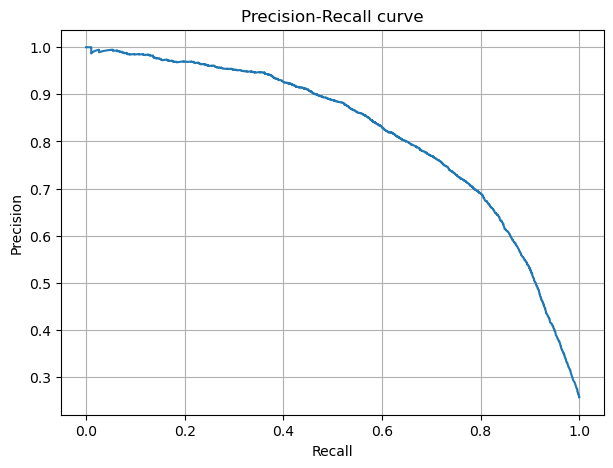

In [17]:
plt.figure(figsize=(7,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.grid(True)
plt.show()


In [18]:
# Mostrar los features importantes para el XGBoost 

preprocess = model.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

importances = model.named_steps["xgb"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

importance_df.head(15)


,feature,importance
29,num__recency_score,0.233766
20,cat__has_singleplayer_0,0.144910
25,num__num_stores,0.142718
28,num__years_since_release,0.094749
23,cat__is_indie_1,0.057684
21,cat__has_singleplayer_1,0.056677
6,cat__esrb_name_Unknown,0.035176
22,cat__is_indie_0,0.032190
14,cat__release_year_2023.0,0.026686
2,cat__esrb_name_Everyone 10+,0.019757


## 9) Guardar modelo


In [26]:
import joblib
from datetime import datetime
from pathlib import Path

out_dir = Path("models")
out_dir.mkdir(parents=True, exist_ok=True)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = out_dir / f"xgb_success_model_{stamp}.pkl"
success_features = out_dir/ f"success_features.pkl"

joblib.dump(model, model_path)
joblib.dump(FEATURES, success_features) 
model_path
success_features


WindowsPath('models/success_features.pkl')

In [29]:
# Comprobación
from pathlib import Path
import joblib

models_dir = Path("models")

# Ver modelos disponibles
model_files = list(models_dir.glob('xgb_success_model_*.pkl'))
print(f"Modelos encontrados: {len(model_files)}")
for f in model_files:
    print(f"  - {f.name}")

# Verificar features
features_file = models_dir / 'success_features.pkl'
if features_file.exists():
    features = joblib.load(features_file)
    print(f"\nFeatures file OK: {len(features)} features")
else:
    print(f"\nFeatures file NO encontrado: {features_file}")

Modelos encontrados: 1
  - xgb_success_model_20260219_121239.pkl

Features file OK: 11 features
